In [91]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('C:/Users/amitp/Downloads/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [93]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [94]:
print(df.describe())

       SeniorCitizen       tenure  MonthlyCharges  TotalCharges
count    7043.000000  7043.000000     7043.000000   7032.000000
mean        0.162147    32.371149       64.761692   2283.300441
std         0.368612    24.559481       30.090047   2266.771362
min         0.000000     0.000000       18.250000     18.800000
25%         0.000000     9.000000       35.500000    401.450000
50%         0.000000    29.000000       70.350000   1397.475000
75%         0.000000    55.000000       89.850000   3794.737500
max         1.000000    72.000000      118.750000   8684.800000


In [95]:
df.select_dtypes(include='number').columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='str')

In [96]:
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [97]:
df['TotalCharges'] = df['TotalCharges'].fillna(
    df['tenure']*df['MonthlyCharges']
)

In [116]:
df.to_csv(
    r'C:\Users\amitp\Downloads\telco_churn_cleaned.csv',
    index=False
)

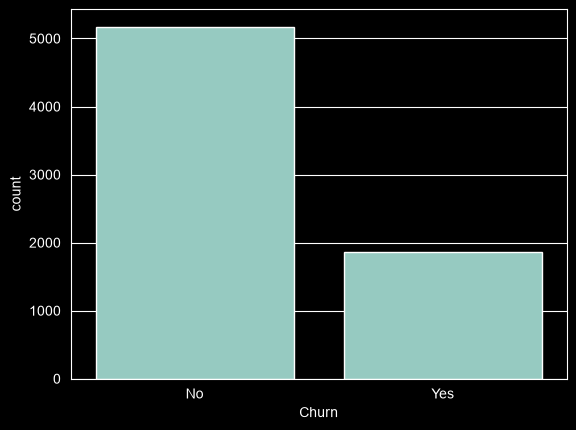

In [99]:
sns.countplot(x='Churn', data=df)
plt.show()

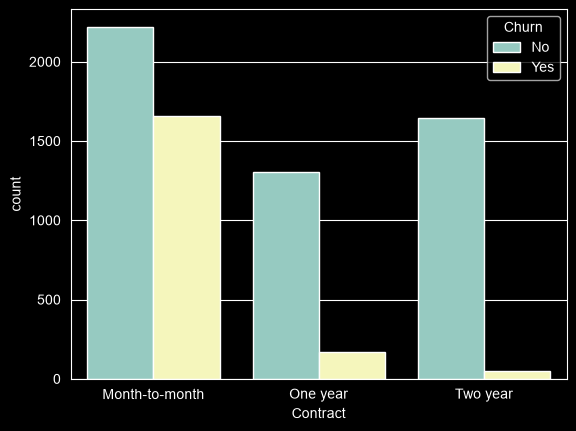

In [100]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

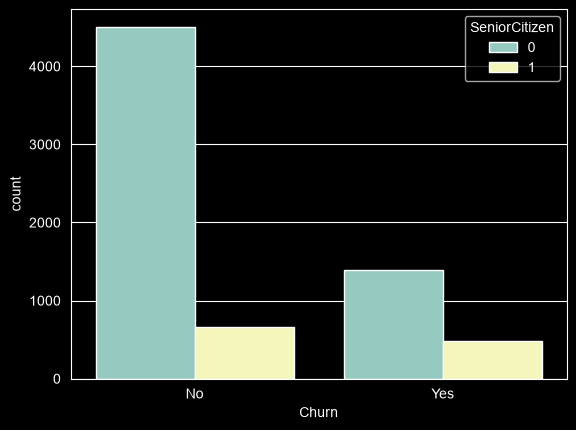

In [101]:
sns.countplot(x='Churn', hue='SeniorCitizen', data=df)
plt.show()

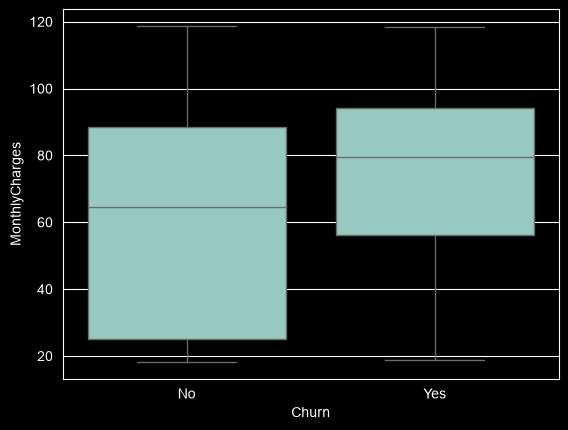

In [102]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [103]:
percentage_chur_age =pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100
print(percentage_chur_age)

Churn                 No        Yes
SeniorCitizen                      
0              76.393832  23.606168
1              58.318739  41.681261


In [104]:
contract_type_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
print(contract_type_churn)
print(df.groupby('Churn')['MonthlyCharges'].describe())

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
No     5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
Yes    1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


In [105]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize = 'index'
)*100
print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


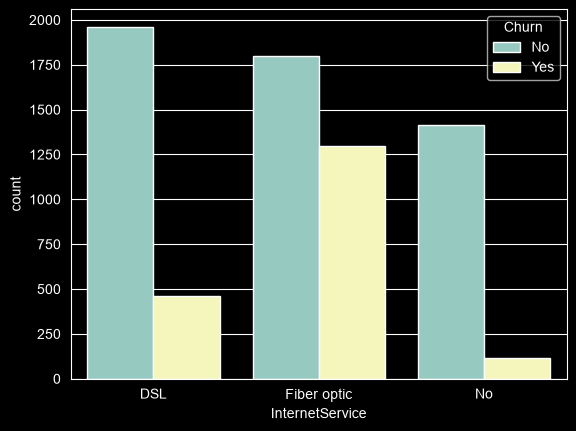

In [106]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.show()

In [107]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
)*100
print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.290155  16.709845
Credit card (automatic)    84.756899  15.243101
Electronic check           54.714588  45.285412
Mailed check               80.893300  19.106700


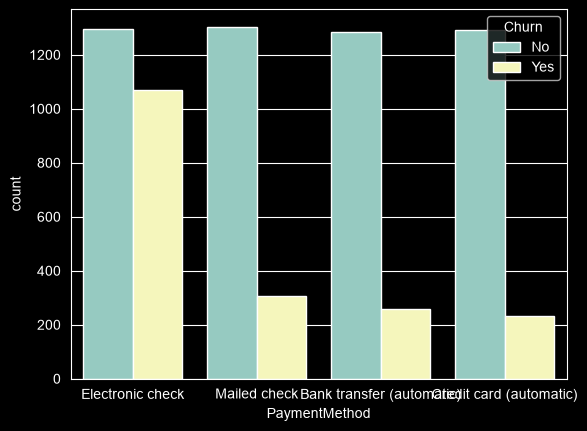

In [108]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.show()

In [109]:
gender_churn = pd.crosstab(
    df['gender'],
    df['Churn'],
    normalize='index'
)*100
print(gender_churn)

Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


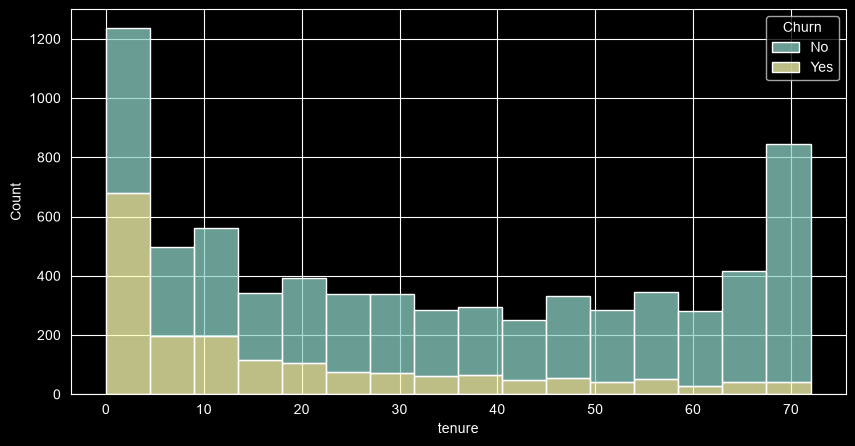

In [110]:
# Analyzing Tenure
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='tenure', hue='Churn', multiple='stack')
plt.show()

In [111]:
# Revenue Impact
churned_customer = df[df['Churn'] == 'Yes']

print(
    "Revenue at Risk:",
    churned_customer['MonthlyCharges'].sum()
)

Revenue at Risk: 139130.85


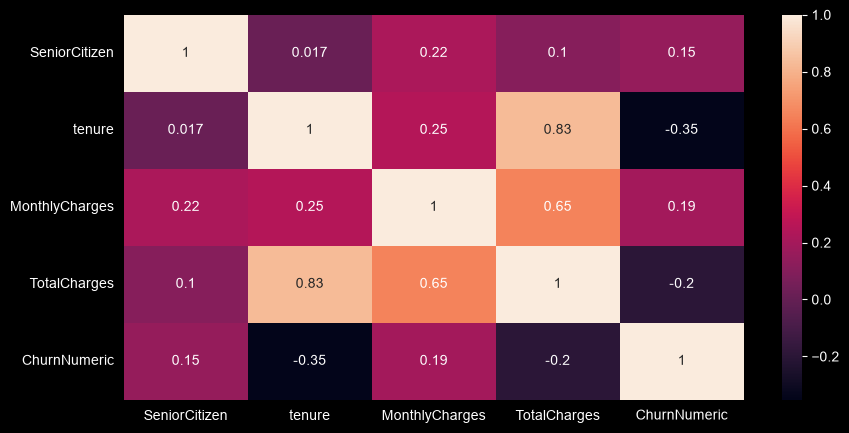

In [112]:
# Correlation Analysis
df['ChurnNumeric'] = df['Churn'].map({
    'Yes': 1,
    'No': 0
})

numeric_cols = df.select_dtypes(include='number')
corr = numeric_cols.corr()

plt.figure(figsize=(10,5))
sns.heatmap(corr, annot=True)
plt.show()

In [113]:
# Customer Segmentation

df['TenureGroup'] = pd.cut(
    df['tenure'],
    bins=[0,12,24,48,72],
    labels=[
        '0-1 Year',
        '1-2 Year',
        '2-4 Year',
        '4-6 Year',
    ],
    include_lowest=True,
)

customer_seg = pd.crosstab(
    df['TenureGroup'],
    df['Churn'],
    normalize='index'
) * 100
print(customer_seg)

Churn               No        Yes
TenureGroup                      
0-1 Year     52.561757  47.438243
1-2 Year     71.289062  28.710938
2-4 Year     79.611041  20.388959
4-6 Year     90.486824   9.513176


In [114]:
"""
Key Findings
1. Month-to-month customers have the highest churn rate.
2. Senior citizens churn more frequently.
3. Customers with short tenure are more likely to churn.
4. Customers with higher monthly charges show greater churn propensity.
5. Electronic check users have the highest churn rate.
6. Longer contract durations significantly reduce churn.

"""

'\nKey Findings\n1. Month-to-month customers have the highest churn rate.\n2. Senior citizens churn more frequently.\n3. Customers with short tenure are more likely to churn.\n4. Customers with higher monthly charges show greater churn propensity.\n5. Electronic check users have the highest churn rate.\n6. Longer contract durations significantly reduce churn.\n\n'

In [115]:
print(df.columns)

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'ChurnNumeric', 'TenureGroup'],
      dtype='str')
